# EMPCA Component Interpretation (Publication-Grade Verification)

This notebook rigorously verifies interpretation of EMPCA components \(u_1, u_2, u_3\) for the **current implementation and training pipeline**.

All primary analysis is performed in the **same transformed domain used in training** (baseline-corrected traces + `ti_rfft`, weighted EMPCA), not raw time-domain pulse space.


## 1. Introduction

**Goal**  
Validate component interpretation with metric-based and subspace-based evidence, and separate fixed physical references from exploratory diagnostics.

**Method**  
Use saved artifacts from the actual training pipeline (`train_empca_sum_channel.py`) and compare in transformed space using weighted inner products and principal-angle tests.

**Interpretation Meaning**  
EMPCA here learns dominant directions of a **shift-invariant transformed pulse manifold**. This is not a direct raw time-domain basis decomposition.

### Pipeline Facts (Current Codebase)

1. Baseline removal (per trace)  
2. `ti_rfft` transform  
3. Weighted EMPCA fit (diagonal metric)  
4. Smoothed eigenvectors + orthonormalization in implementation

\[
	ext{Training-space metric:}\quad \langle a,b
angle_W = \sum_f a^*(f) W(f) b(f)
\]


In [19]:
# Global style + top-level config
from pathlib import Path

MODEL_PATH = Path('wk3/models/PSD_run1_sum_mmc.pkl')
TEMPLATE_PATH = Path('reusable/template/QP_template.npy')

MAX_TRACES = 1000
TIMING_MAX_TRACES = 300
TIMING_MAX_LAG = 256
RUN_EXPENSIVE = True
RUN_STABILITY = True

FS_HZ = 1.0  # if unknown, keep 1.0 for relative derivative scale only

SHIFT_GRID = list(range(-24, 25, 2))
SHAPE_ALPHA_GRID = [-0.30, -0.20, -0.10, 0.10, 0.20, 0.30]

print('MODEL_PATH =', MODEL_PATH)
print('TEMPLATE_PATH =', TEMPLATE_PATH)
print('MAX_TRACES =', MAX_TRACES)


MODEL_PATH = wk3/models/PSD_run1_sum_mmc.pkl
TEMPLATE_PATH = reusable/template/QP_template.npy
MAX_TRACES = 1000


In [20]:
# Imports and path handling
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from scipy.interpolate import interp1d

# Publication-friendly plot settings
plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'lines.linewidth': 1.5,
})

start = Path.cwd().resolve()
repo_root = None
for cand in (start, *start.parents):
    if (cand / 'wk3' / 'models').exists() and (cand / 'reusable').exists():
        repo_root = cand
        break
if repo_root is None:
    raise RuntimeError('Could not locate repo root')

sys.path.insert(0, str(repo_root / 'reusable'))
from empca_TCY_optimized import ti_rfft, ti_irfft

MODEL_PATH_ABS = MODEL_PATH if MODEL_PATH.is_absolute() else (repo_root / MODEL_PATH).resolve()
TEMPLATE_PATH_ABS = TEMPLATE_PATH if TEMPLATE_PATH.is_absolute() else (repo_root / TEMPLATE_PATH).resolve()

print('repo_root:', repo_root)
print('MODEL_PATH_ABS:', MODEL_PATH_ABS)
print('TEMPLATE_PATH_ABS:', TEMPLATE_PATH_ABS)


repo_root: /home/dwong/DELight_mtr/PCA_dev
MODEL_PATH_ABS: /home/dwong/DELight_mtr/PCA_dev/wk3/models/PSD_run1_sum_mmc.pkl
TEMPLATE_PATH_ABS: /home/dwong/DELight_mtr/PCA_dev/reusable/template/QP_template.npy


## 2. Load Model and Data

**Goal**  
Load exactly the saved artifact structure used by training.

**Method**  
Read pickle artifact and extract `pca`, `cfg`, weighting metadata, dataset metadata.

**Interpretation Meaning**  
`U = pca.eigvec` are learned transformed-domain basis vectors; `C = pca.coeff` are fitted latent coefficients in that basis.


In [21]:
# Load artifact and core fields
with open(MODEL_PATH_ABS, 'rb') as f:
    artifact = pickle.load(f)

if not isinstance(artifact, dict):
    raise TypeError('Expected dict artifact')

pca = artifact['pca']
cfg = artifact['cfg']
weight_type = artifact.get('weight_type', 'unknown')
noise_type = artifact.get('noise_type', 'unknown')
psd_eff = artifact.get('psd_eff', None)
snr2_weight_path = artifact.get('snr2_weight_path', None)
dataset_paths = artifact.get('dataset_paths', [])
trace_key = artifact.get('trace_key', 'traces')
keep_mask = artifact.get('keep_mask', None)

U = np.asarray(getattr(pca, 'eigvec', getattr(pca, 'components_', None)), dtype=complex)
C_saved = np.asarray(getattr(pca, 'coeff', np.empty((0, 0))), dtype=complex)

if U is None:
    raise AttributeError('No eigvec/components_ found in PCA object')

print('artifact keys:', sorted(artifact.keys()))
print('weight_type:', weight_type)
print('noise_type:', noise_type)
print('trace_key:', trace_key)
print('n dataset_paths:', len(dataset_paths))
print('keep_mask shape:', None if keep_mask is None else keep_mask.shape)
print('U shape:', U.shape)
print('C_saved shape:', C_saved.shape)
if psd_eff is not None:
    print('psd_eff shape:', np.asarray(psd_eff).shape)
if snr2_weight_path is not None:
    print('snr2_weight_path:', snr2_weight_path)


artifact keys: ['cfg', 'dataset', 'dataset_paths', 'energy_ev', 'keep_mask', 'n_batches', 'noise_type', 'pca', 'psd_eff', 'psd_path', 'trace_key', 'weight_type']
weight_type: 1/PSD
noise_type: mmc
trace_key: traces_MMC
n dataset_paths: 10
keep_mask shape: (1000,)
U shape: (4, 16385)
C_saved shape: (735, 4)
psd_eff shape: (16385,)


## 3. Reconstruct Training Domain

**Goal**  
Reconstruct representative training-domain data context.

**Method**  
Load traces using artifact metadata, apply baseline correction and `ti_rfft` exactly as training pipeline logic.

**Interpretation Meaning**  
All component interpretation claims are validated where EMPCA was actually trained.


In [22]:
# Training-style trace loading helper

def load_traces_from_artifact(artifact_dict, max_traces=1000):
    paths = artifact_dict.get('dataset_paths', [])
    key = artifact_dict.get('trace_key', 'traces')
    if not paths:
        return None, 'dataset_paths missing'

    chunks = []
    loaded = 0
    for p in paths:
        fp = Path(p)
        if not fp.exists():
            continue
        with h5py.File(fp, 'r') as f:
            if key not in f:
                continue
            arr = np.asarray(f[key][:], dtype=float)
            if arr.ndim == 3:  # expected (N,1,T)
                arr = arr[:, 0, :]
            elif arr.ndim != 2:
                continue
            rem = max_traces - loaded
            if rem <= 0:
                break
            take = min(rem, arr.shape[0])
            chunks.append(arr[:take])
            loaded += take
            if loaded >= max_traces:
                break

    if not chunks:
        return None, f'no readable local files for key={key}'
    return np.concatenate(chunks, axis=0), None


X_time, load_err = load_traces_from_artifact(artifact, max_traces=MAX_TRACES)
if X_time is None:
    print('Trace load unavailable:', load_err)
else:
    print('X_time shape:', X_time.shape)


X_time shape: (1000, 32768)


In [23]:
# Baseline correction + ti_rfft (training-domain preprocessing)

def baseline_correct_per_trace(X, pretrigger=4000, method='mean'):
    X = np.asarray(X, dtype=float)
    pre = X[:, :pretrigger]
    if method == 'median':
        b = np.median(pre, axis=1)
    else:
        b = np.mean(pre, axis=1)
    return X - b[:, None], b

if X_time is not None:
    pretrigger = int(cfg.get('pretrigger', 4000))
    baseline_method = cfg.get('baseline_method', 'mean')
    X0, baseline = baseline_correct_per_trace(X_time, pretrigger=pretrigger, method=baseline_method)
    Xf = np.asarray(ti_rfft(X0), dtype=complex)
    print('Xf shape:', Xf.shape)
else:
    X0, baseline, Xf = None, None, None


Xf shape: (1000, 16385)


In [24]:
# Reconstruct training-consistent weight vector W

def resolve_weight_vector(artifact_dict, repo):
    n_freq = U.shape[1]
    wt = artifact_dict.get('weight_type', 'unknown')
    if wt == '1/PSD':
        psd = np.asarray(artifact_dict['psd_eff'], dtype=float)
        Wloc = 1.0 / np.maximum(psd, 1e-30)
    elif 'snr2_weight_path' in artifact_dict:
        wp = Path(artifact_dict['snr2_weight_path'])
        if not wp.is_absolute():
            wp = (repo / wp).resolve()
        if not wp.exists():
            raise FileNotFoundError(f'Missing SNR2 weight file: {wp}')
        Wloc = np.asarray(np.load(wp), dtype=float)
    else:
        raise RuntimeError('Cannot resolve weight vector from artifact')
    if len(Wloc) != n_freq:
        raise ValueError(f'Weight length mismatch: {len(Wloc)} vs {n_freq}')
    return Wloc

W = resolve_weight_vector(artifact, repo_root)
print('W shape:', W.shape, 'min/max:', float(np.min(W)), float(np.max(W)))


W shape: (16385,) min/max: 727.770933918662 582032.7218170777


## 4. Define Metric

**Goal**  
Use the exact weighted metric relevant to training objective.

**Method**  
Implement weighted inner product, weighted cosine, weighted projection, and weighted \(R^2\).

**Interpretation Meaning**  
Visual overlays can be misleading. Metric-based evaluation in training geometry is required.

\[
\langle a,b
angle_W = \sum_f a^*(f)W(f)b(f)
\]


In [25]:
# Metric/projection helpers (complex-safe)

def weighted_inner(a, b, w):
    a = np.asarray(a, dtype=complex).ravel()
    b = np.asarray(b, dtype=complex).ravel()
    w = np.asarray(w, dtype=float).ravel()
    return np.sum(np.conj(a) * w * b)


def weighted_norm(a, w):
    v = np.real(weighted_inner(a, a, w))
    return np.sqrt(max(v, 0.0))


def weighted_cosine(a, b, w):
    den = weighted_norm(a, w) * weighted_norm(b, w)
    if den <= 0:
        return np.nan + 0j
    return weighted_inner(a, b, w) / den


def normalize_weighted(a, w, eps=1e-30):
    n = weighted_norm(a, w)
    if n < eps:
        return np.asarray(a, dtype=complex)
    return np.asarray(a, dtype=complex) / n


def weighted_ls(B, y, w, ridge=1e-18):
    B = np.asarray(B, dtype=complex)
    y = np.asarray(y, dtype=complex)
    w = np.asarray(w, dtype=float)
    G = B.conj().T @ (w[:, None] * B)
    G = G + ridge * np.eye(G.shape[0], dtype=complex)
    rhs = B.conj().T @ (w * y)
    c = np.linalg.solve(G, rhs)
    yhat = B @ c
    return c, yhat


def weighted_r2(y, yhat, w):
    err = y - yhat
    sse = np.real(weighted_inner(err, err, w))
    sst = np.real(weighted_inner(y, y, w))
    r2 = 1.0 - sse / max(sst, 1e-30)
    return r2, np.sqrt(max(sse, 0.0))


def align_phase_to_ref(v, ref, w):
    z = weighted_inner(ref, v, w)
    if np.abs(z) < 1e-30:
        return v
    return v * np.exp(-1j * np.angle(z))


def weighted_principal_angles(Ub, Rb, w):
    sqrtw = np.sqrt(w)
    Uw = (sqrtw[None, :] * Ub).T
    Rw = (sqrtw[None, :] * Rb).T
    Qu, _ = np.linalg.qr(Uw)
    Qr, _ = np.linalg.qr(Rw)
    s = np.linalg.svd(Qu.conj().T @ Qr, compute_uv=False)
    s = np.clip(np.real(s), -1.0, 1.0)
    return np.degrees(np.arccos(s))


## 5. Reference Construction

### 5A. Fixed Physical References (Predefined)

**Goal**  
Build physically motivated references **before** exploratory component matching.

**Method**  
Construct template and derivative candidates in transformed domain; construct residual shape candidate from traces by removing fixed template+derivative directions.

**Interpretation Meaning**  
These references are primary hypothesis tests and are not tuned to maximize fit to EMPCA components.


In [26]:
# Fixed references: template, derivative candidates, shape candidate

template_time = np.asarray(np.load(TEMPLATE_PATH_ABS), dtype=float).ravel()

if len(template_time) != (2 * U.shape[1] - 2):
    raise ValueError(f'Template length {len(template_time)} incompatible with component n_freq={U.shape[1]}')

# Baseline convention: keep template as provided (training used baseline-corrected traces)
r_template_time = template_time.copy()
r_template_freq = np.asarray(ti_rfft(r_template_time), dtype=complex).ravel()

def shift_signal(sig, shift_samples):
    n = len(sig)
    t = np.arange(n)
    f = interp1d(t, sig, kind='cubic', bounds_error=False, fill_value=(sig[0], sig[-1]))
    return f(t - shift_samples)

# Derivative candidates
dt = 1.0 / FS_HZ
deriv_time_grad = np.gradient(template_time, dt)
deriv_freq_grad = np.asarray(ti_rfft(deriv_time_grad), dtype=complex).ravel()

delta = 1.0
deriv_time_shift = (shift_signal(template_time, +delta) - shift_signal(template_time, -delta)) / (2.0 * delta)
deriv_freq_shift = np.asarray(ti_rfft(deriv_time_shift), dtype=complex).ravel()

s_plus = np.asarray(ti_rfft(shift_signal(template_time, +delta)), dtype=complex).ravel()
s_minus = np.asarray(ti_rfft(shift_signal(template_time, -delta)), dtype=complex).ravel()
deriv_freq_transformed = (s_plus - s_minus) / (2.0 * delta)

fixed_derivative_refs = {
    'D1_grad_time_then_transform': deriv_freq_grad,
    'D2_shiftfd_time_then_transform': deriv_freq_shift,
    'D3_shiftfd_in_transformed_domain': deriv_freq_transformed,
}

# Fixed shape candidate: residual PCA after removing template + fixed derivative D2
shape_candidate_name = 'S1_residual_pca_after_template_D2'
if Xf is not None and RUN_EXPENSIVE:
    B_fix = np.column_stack([
        normalize_weighted(r_template_freq, W),
        normalize_weighted(fixed_derivative_refs['D2_shiftfd_time_then_transform'], W),
    ])
    Xres = np.empty_like(Xf)
    for i in range(Xf.shape[0]):
        _, xhat = weighted_ls(B_fix, Xf[i], W)
        Xres[i] = Xf[i] - xhat
    Xres_centered = Xres - np.mean(Xres, axis=0, keepdims=True)
    _, _, Vh = np.linalg.svd(Xres_centered, full_matrices=False)
    fixed_shape_ref = np.asarray(Vh[0], dtype=complex)
    shape_msg = f'computed from residual PCA using traces (n={Xf.shape[0]})'
else:
    # fallback (clearly marked): proxy from u3 residual
    B_fix = np.column_stack([
        normalize_weighted(r_template_freq, W),
        normalize_weighted(fixed_derivative_refs['D2_shiftfd_time_then_transform'], W),
    ])
    _, u3hat = weighted_ls(B_fix, U[2], W)
    fixed_shape_ref = U[2] - u3hat
    shape_msg = 'fallback proxy from u3 residual (trace data unavailable)'

fixed_refs = {
    'Template': r_template_freq,
    **fixed_derivative_refs,
    shape_candidate_name: fixed_shape_ref,
}

print('Fixed refs:', list(fixed_refs.keys()))
print('Shape candidate status:', shape_msg)


Fixed refs: ['Template', 'D1_grad_time_then_transform', 'D2_shiftfd_time_then_transform', 'D3_shiftfd_in_transformed_domain', 'S1_residual_pca_after_template_D2']
Shape candidate status: computed from residual PCA using traces (n=1000)


### 5B. Exploratory Best-Match References (Data-Driven)

**Goal**  
Build exploratory diagnostics after observing component/reference overlaps.

**Method**  
Pick best derivative-like and shape-like candidates by weighted cosine to specific components.

**Interpretation Meaning**  
These are **diagnostic aids**, not primary proof. Fixed references remain the main basis for claims.


In [27]:
# Exploratory best-match references (post-hoc diagnostics)

u2 = U[1]
u3 = U[2]

deriv_diag = []
for name, vec in fixed_derivative_refs.items():
    vec_a = align_phase_to_ref(vec, u2, W)
    c = weighted_cosine(u2, vec_a, W)
    _, yhat = weighted_ls(vec_a[:, None], u2, W)
    r2, rn = weighted_r2(u2, yhat, W)
    deriv_diag.append({'name': name, 'cosine_real': float(np.real(c)), 'cosine_imag': float(np.imag(c)), 'R2': float(r2), 'resid_norm': float(rn), 'vec': vec_a})

deriv_diag = sorted(deriv_diag, key=lambda d: d['cosine_real'], reverse=True)
best_deriv_expl_name = deriv_diag[0]['name']
best_deriv_expl_vec = deriv_diag[0]['vec']

shape_diag = []
shape_candidates = {
    shape_candidate_name: fixed_shape_ref,
}
for name, vec in shape_candidates.items():
    vec_a = align_phase_to_ref(vec, u3, W)
    c = weighted_cosine(u3, vec_a, W)
    _, yhat = weighted_ls(vec_a[:, None], u3, W)
    r2, rn = weighted_r2(u3, yhat, W)
    shape_diag.append({'name': name, 'cosine_real': float(np.real(c)), 'cosine_imag': float(np.imag(c)), 'R2': float(r2), 'resid_norm': float(rn), 'vec': vec_a})

shape_diag = sorted(shape_diag, key=lambda d: d['cosine_real'], reverse=True)
best_shape_expl_name = shape_diag[0]['name']
best_shape_expl_vec = shape_diag[0]['vec']

print('Exploratory best derivative:', best_deriv_expl_name)
print('Exploratory best shape:', best_shape_expl_name)


Exploratory best derivative: D2_shiftfd_time_then_transform
Exploratory best shape: S1_residual_pca_after_template_D2


## 6. Verification of \(u_1\)

**Goal**  
Test whether \(u_1\) is template-like in transformed domain.

**Method**  
Compute weighted cosine, projection coefficient, weighted \(R^2\), residual norm; show transformed-domain and inverse-transformed overlays.

**Interpretation Meaning**  
High weighted cosine and high \(R^2\) support dominant template alignment in training geometry.


u1 vs template metrics:
  weighted cosine (real, imag): 0.8658830793516827 -9.31121764483342e-18
  projection coeff: (4.754110315961435e-05+2.6371988977452756e-21j)
  weighted R2: 0.7497535071075523
  residual norm: 12.687770058484038


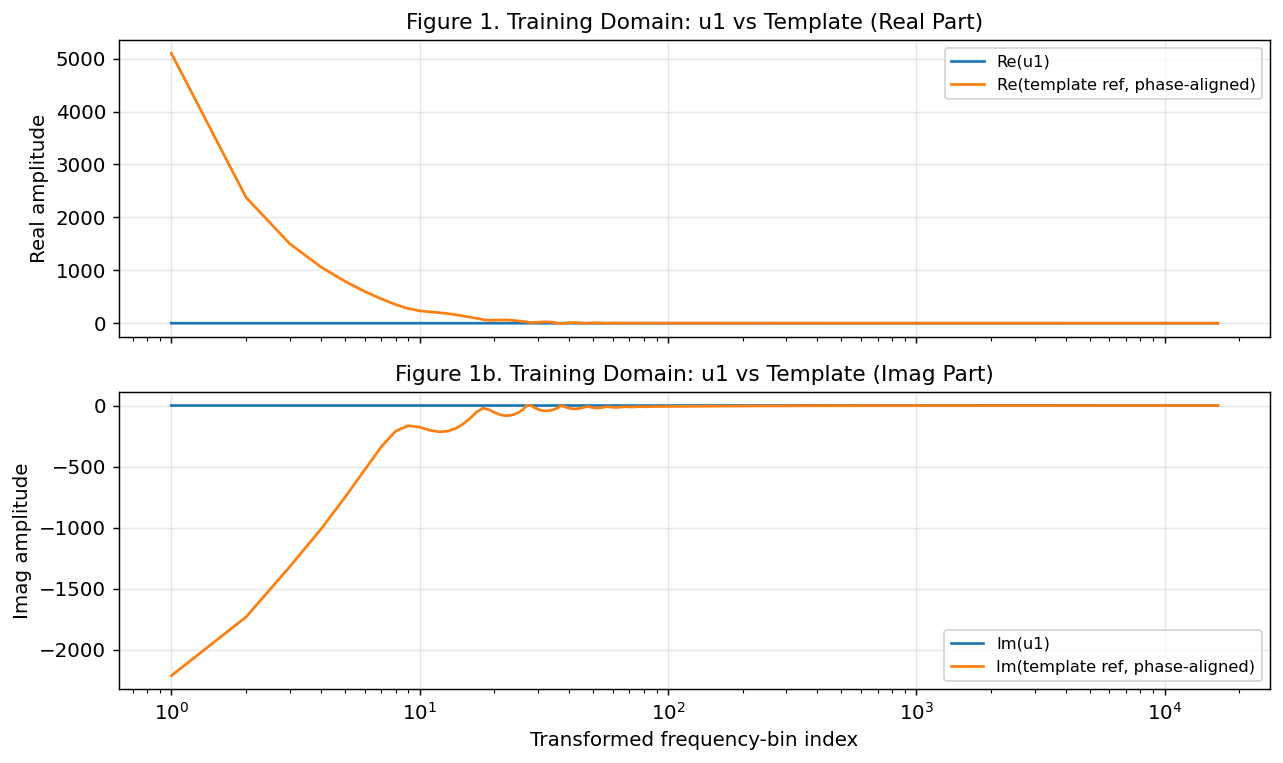

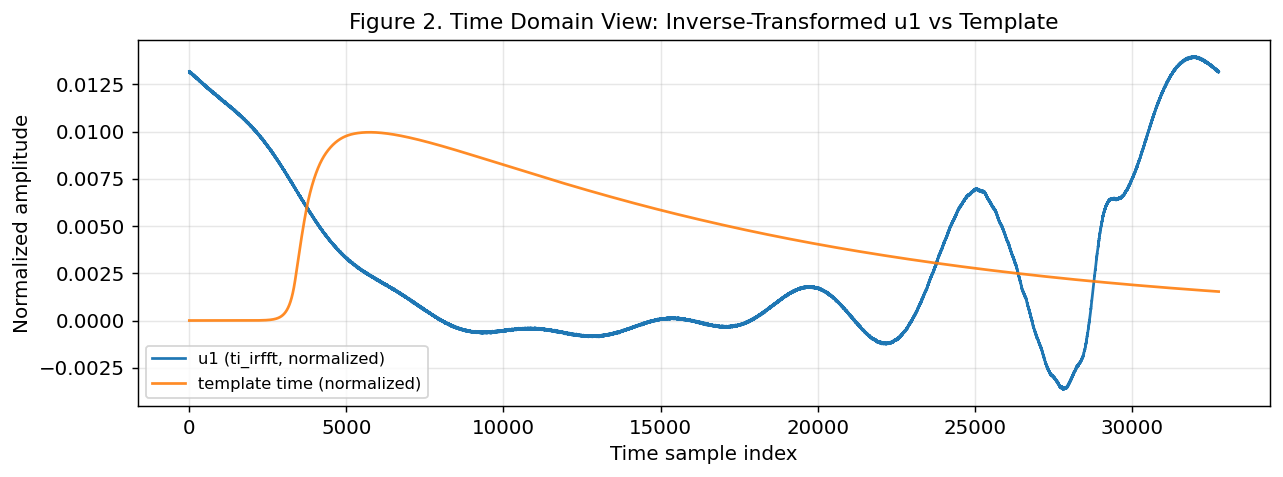

In [28]:
# Metrics + Figure 1 + Figure 2 for u1
u1 = U[0]
tmpl_aligned = align_phase_to_ref(r_template_freq, u1, W)

cos_u1 = weighted_cosine(u1, tmpl_aligned, W)
coef_u1, u1_hat = weighted_ls(tmpl_aligned[:, None], u1, W)
r2_u1, rn_u1 = weighted_r2(u1, u1_hat, W)

print('u1 vs template metrics:')
print('  weighted cosine (real, imag):', float(np.real(cos_u1)), float(np.imag(cos_u1)))
print('  projection coeff:', coef_u1[0])
print('  weighted R2:', float(r2_u1))
print('  residual norm:', float(rn_u1))

# Figure 1: transformed-domain overlay (real + imag)
xlog = np.arange(1, len(u1), dtype=float)
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(xlog, np.real(u1[1:]), label='Re(u1)')
axes[0].plot(xlog, np.real(tmpl_aligned[1:]), label='Re(template ref, phase-aligned)')
axes[0].set_title('Figure 1. Training Domain: u1 vs Template (Real Part)')
axes[0].set_ylabel('Real amplitude')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(xlog, np.imag(u1[1:]), label='Im(u1)')
axes[1].plot(xlog, np.imag(tmpl_aligned[1:]), label='Im(template ref, phase-aligned)')
axes[1].set_title('Figure 1b. Training Domain: u1 vs Template (Imag Part)')
axes[1].set_xlabel('Transformed frequency-bin index')
axes[1].set_ylabel('Imag amplitude')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[0].set_xscale('log')
axes[1].set_xscale('log')
plt.tight_layout()
plt.show()

# Figure 2: time-domain overlay via ti_irfft
u1_t = np.asarray(ti_irfft(u1), dtype=float).ravel()
t_t = template_time.copy()

# Visualization normalization only
u1_tn = u1_t / (np.linalg.norm(u1_t) + 1e-30)
t_tn = t_t / (np.linalg.norm(t_t) + 1e-30)
if np.dot(u1_tn, t_tn) < 0:
    u1_tn = -u1_tn

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(u1_tn, label='u1 (ti_irfft, normalized)')
ax.plot(t_tn, label='template time (normalized)', alpha=0.9)
ax.set_title('Figure 2. Time Domain View: Inverse-Transformed u1 vs Template')
ax.set_xlabel('Time sample index')
ax.set_ylabel('Normalized amplitude')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Verification of \(u_2\)

**Goal**  
Determine whether \(u_2\) is derivative-like / timing-like or a broader residual deformation mode.

**Method**  
(1) Compare against all derivative candidates, (2) correlate coefficient \(c_2\) with timing proxy \(t_0\), (3) measure controlled shift perturbation response.

**Interpretation Meaning**  
Systematic \(c_2\)-shift dependence plus timing correlation supports timing-like interpretation.


                          candidate  cosine_real   cosine_imag        R2  \
0    D2_shiftfd_time_then_transform     0.674125 -7.550448e-17  0.454445   
1       D1_grad_time_then_transform     0.674112 -8.741749e-17  0.454427   
2  D3_shiftfd_in_transformed_domain     0.236088 -1.011738e-16  0.055737   

   resid_norm  
0   20.174462  
1   20.174784  
2   26.541713  


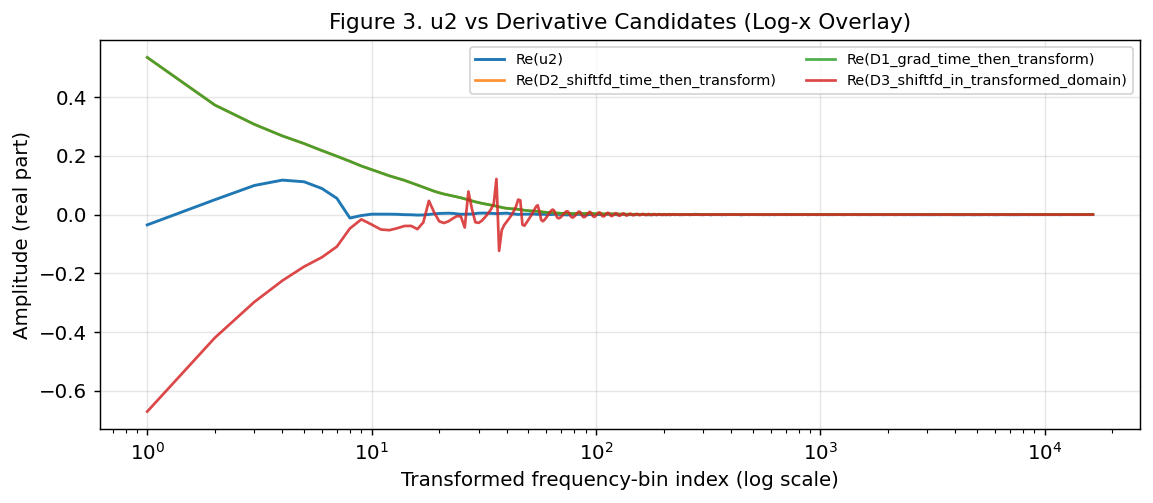

In [29]:
# 7.1 Derivative comparison (Figure 3)
u2 = U[1]

rows = []
for name, d in fixed_derivative_refs.items():
    d_a = align_phase_to_ref(d, u2, W)
    c = weighted_cosine(u2, d_a, W)
    _, yhat = weighted_ls(d_a[:, None], u2, W)
    r2, rn = weighted_r2(u2, yhat, W)
    rows.append({'candidate': name, 'cosine_real': float(np.real(c)), 'cosine_imag': float(np.imag(c)), 'R2': float(r2), 'resid_norm': float(rn), 'vec': d_a})

deriv_df = pd.DataFrame(rows).sort_values('cosine_real', ascending=False).reset_index(drop=True)
print(deriv_df[['candidate', 'cosine_real', 'cosine_imag', 'R2', 'resid_norm']])

xlog = np.arange(1, len(u2), dtype=float)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(xlog, np.real(u2[1:]), label='Re(u2)', linewidth=1.6)
for _, r in deriv_df.iterrows():
    vec = r['vec']
    ax.plot(xlog, np.real(vec[1:]), label=f"Re({r['candidate']})", alpha=0.85)
ax.set_xscale('log')
ax.set_xlabel('Transformed frequency-bin index (log scale)')
ax.set_ylabel('Amplitude (real part)')
ax.set_title('Figure 3. u2 vs Derivative Candidates (Log-x Overlay)')
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


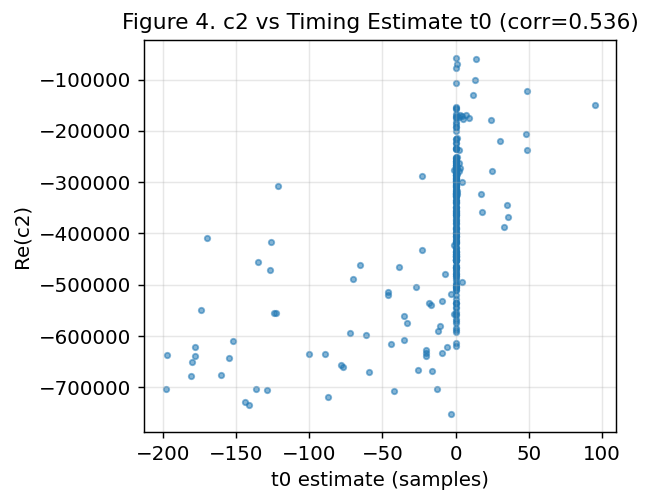

In [30]:
# 7.2 Timing correlation: c2 vs t0 (Figure 4)

def estimate_t0_fft_window(traces, template, max_lag=256):
    traces = np.asarray(traces, dtype=float)
    t = template - np.mean(template)
    n = traces.shape[1]
    nfft = 1
    while nfft < 2*n - 1:
        nfft *= 2
    T = np.fft.rfft(t[::-1], n=nfft)
    full_lags = np.arange(-(n-1), n)
    keep = (full_lags >= -max_lag) & (full_lags <= max_lag)

    out = np.zeros(traces.shape[0], dtype=float)
    for i in range(traces.shape[0]):
        x = traces[i] - np.mean(traces[i])
        X = np.fft.rfft(x, n=nfft)
        cc = np.fft.irfft(X * T, n=nfft)[:2*n-1]
        ccw = cc[keep]
        lagw = full_lags[keep]
        out[i] = lagw[np.argmax(ccw)]
    return out

if Xf is None:
    print('Figure 4 skipped: traces unavailable')
    c2_vs_t0_corr = np.nan
else:
    n_use = min(TIMING_MAX_TRACES, Xf.shape[0])
    B3 = U[:3].T
    coeff = np.zeros((n_use, 3), dtype=complex)
    for i in range(n_use):
        c, _ = weighted_ls(B3, Xf[i], W)
        coeff[i] = c
    c2 = np.real(coeff[:, 1])
    t0 = estimate_t0_fft_window(X0[:n_use], template_time, max_lag=TIMING_MAX_LAG)
    c2_vs_t0_corr = float(np.corrcoef(c2, t0)[0, 1])

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.scatter(t0, c2, s=9, alpha=0.55)
    ax.set_title(f'Figure 4. c2 vs Timing Estimate t0 (corr={c2_vs_t0_corr:.3f})')
    ax.set_xlabel('t0 estimate (samples)')
    ax.set_ylabel('Re(c2)')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


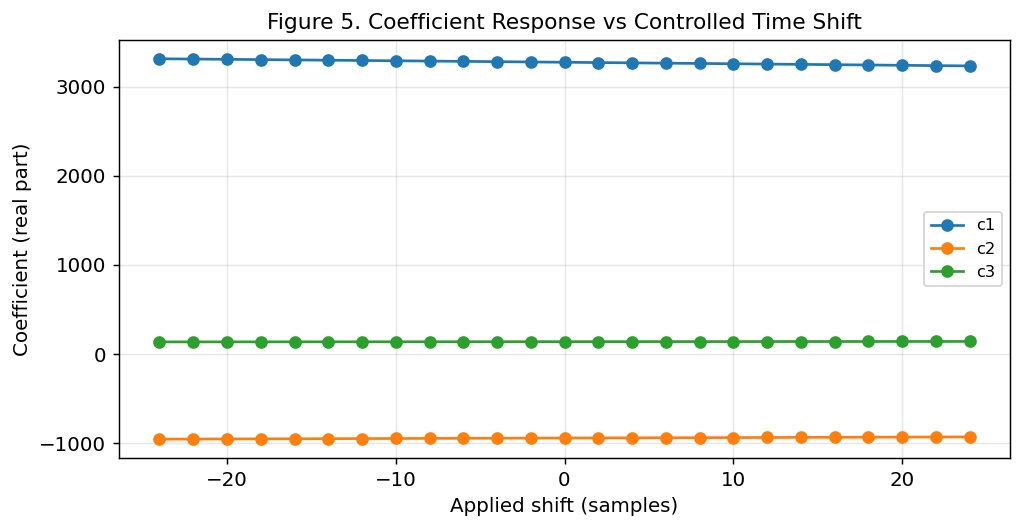

c2 shift sensitivity slope: 0.5183771903295425


In [31]:
# 7.3 Controlled shift perturbation (Figure 5)
# Control conditions: amplitude normalized, same baseline convention, only shift changes.

def normalize_peak(x):
    x = np.asarray(x, dtype=float)
    m = np.max(np.abs(x))
    return x / (m + 1e-30)

def project_to_u123(vec_f, U3, w):
    c, _ = weighted_ls(U3.T, vec_f, w)
    return c

U3 = U[:3]
shift_records = []
for sh in SHIFT_GRID:
    s = shift_signal(template_time, sh)
    s = normalize_peak(s)
    s = s - np.mean(s[:int(cfg.get('pretrigger', 4000))])  # baseline convention
    sf = np.asarray(ti_rfft(s), dtype=complex).ravel()
    c = project_to_u123(sf, U3, W)
    shift_records.append((sh, np.real(c[0]), np.real(c[1]), np.real(c[2])))

shift_arr = np.asarray(shift_records, dtype=float)

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(shift_arr[:,0], shift_arr[:,1], '-o', label='c1')
ax.plot(shift_arr[:,0], shift_arr[:,2], '-o', label='c2')
ax.plot(shift_arr[:,0], shift_arr[:,3], '-o', label='c3')
ax.set_title('Figure 5. Coefficient Response vs Controlled Time Shift')
ax.set_xlabel('Applied shift (samples)')
ax.set_ylabel('Coefficient (real part)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# timing sensitivity summary (for table)
c2_shift_slope = float(np.polyfit(shift_arr[:,0], shift_arr[:,2], 1)[0])
print('c2 shift sensitivity slope:', c2_shift_slope)


## 8. Verification of \(u_3\)

**Goal**  
Assess whether \(u_3\) is shape-like, mixed, or weakly identifiable.

**Method**  
(1) Compare \(u_3\) with residual/shape candidates using weighted metrics, (2) run controlled shape perturbations (broaden, narrow, rise-modified, decay-modified).

**Interpretation Meaning**  
If \(u_3\) responds systematically to shape-only perturbations, shape-like interpretation is supported.


                           candidate  cosine_real   cosine_imag        R2  \
0    S2_synthetic_broad_minus_narrow     0.477617 -3.490492e-17  0.228118   
1  S1_residual_pca_after_template_D2     0.076682  1.061372e-17  0.005880   

   resid_norm  
0   54.851919  
1   62.249496  


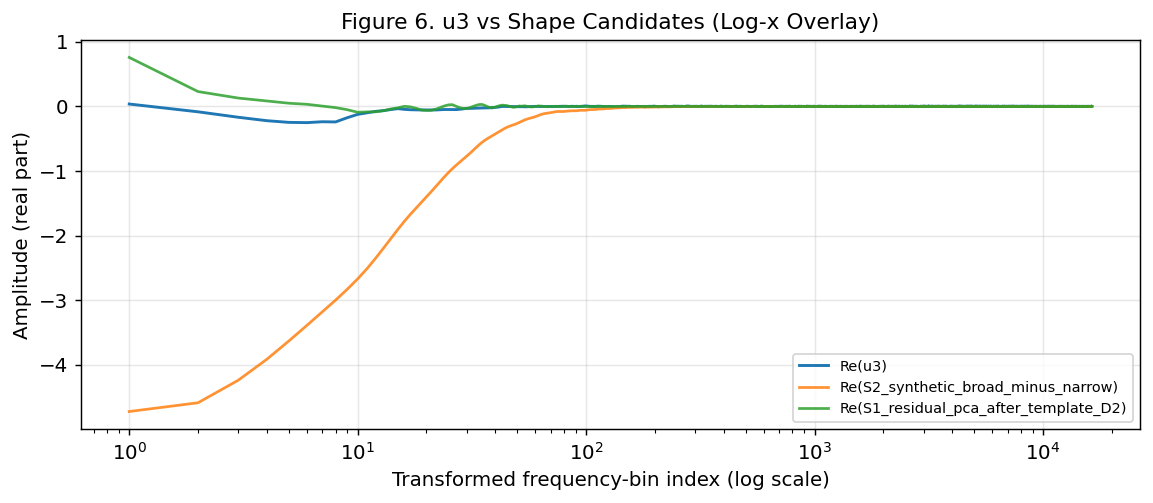

In [32]:
# 8.1 Shape comparison (Figure 6)
u3 = U[2]

# shape candidates: fixed residual PCA + synthetic broad-minus-narrow
shape_synth = np.asarray(ti_rfft((shift_signal(template_time, -2) - shift_signal(template_time, +2))), dtype=complex).ravel()
shape_refs = {
    shape_candidate_name: fixed_shape_ref,
    'S2_synthetic_broad_minus_narrow': shape_synth,
}

rows = []
for name, s in shape_refs.items():
    s_a = align_phase_to_ref(s, u3, W)
    c = weighted_cosine(u3, s_a, W)
    _, yhat = weighted_ls(s_a[:, None], u3, W)
    r2, rn = weighted_r2(u3, yhat, W)
    rows.append({'candidate': name, 'cosine_real': float(np.real(c)), 'cosine_imag': float(np.imag(c)), 'R2': float(r2), 'resid_norm': float(rn), 'vec': s_a})

shape_df = pd.DataFrame(rows).sort_values('cosine_real', ascending=False).reset_index(drop=True)
print(shape_df[['candidate', 'cosine_real', 'cosine_imag', 'R2', 'resid_norm']])

xlog = np.arange(1, len(u3), dtype=float)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(xlog, np.real(u3[1:]), label='Re(u3)', linewidth=1.6)
for _, r in shape_df.iterrows():
    vec = r['vec']
    ax.plot(xlog, np.real(vec[1:]), label=f"Re({r['candidate']})", alpha=0.85)
ax.set_xscale('log')
ax.set_xlabel('Transformed frequency-bin index (log scale)')
ax.set_ylabel('Amplitude (real part)')
ax.set_title('Figure 6. u3 vs Shape Candidates (Log-x Overlay)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


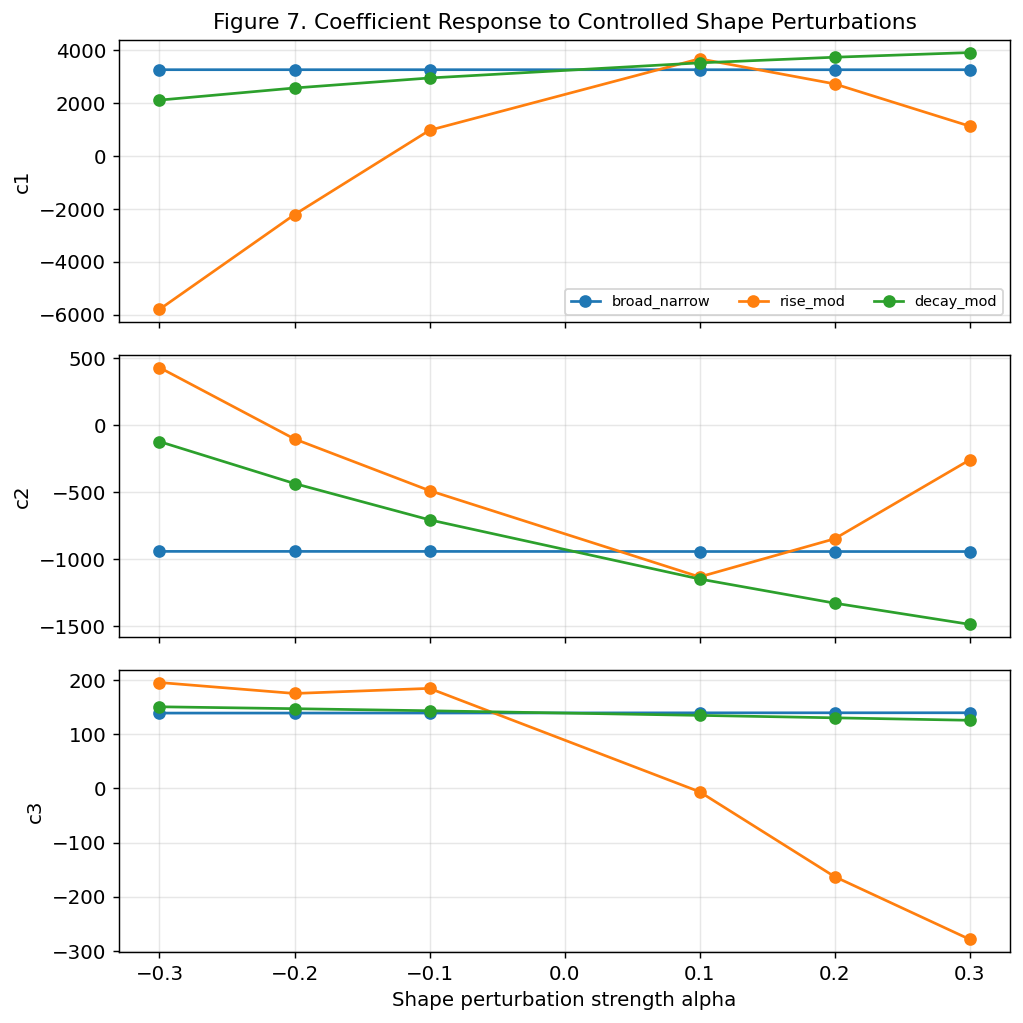

c3 average shape-response span: 166.36132744990942


In [33]:
# 8.2 Controlled shape perturbations (Figure 7)
# Control conditions: normalized amplitude, fixed baseline convention, no explicit global shift.

def mod_rise_time(sig, alpha):
    n = len(sig)
    t = np.linspace(0.0, 1.0, n)
    t2 = np.clip(t**(1.0 + alpha), 0, 1)
    f = interp1d(t2, sig, kind='linear', bounds_error=False, fill_value=(sig[0], sig[-1]))
    return f(t)


def mod_decay_time(sig, alpha):
    n = len(sig)
    t = np.linspace(0.0, 1.0, n)
    w = 1.0 / (1.0 + np.exp(-(t - 0.45) / 0.03))
    decay_scaled = np.exp(-alpha * np.linspace(0, 1, n))
    return sig * ((1-w) + w*decay_scaled)


def broad_narrow(sig, alpha):
    k = np.array([0.2, 0.6, 0.2])
    y = sig.copy()
    steps = max(1, int(1 + 10*abs(alpha)))
    for _ in range(steps):
        y = np.convolve(y, k, mode='same')
    if alpha >= 0:
        return y
    return sig + min(0.9, abs(alpha))*(sig - y)

perts = []
for a in SHAPE_ALPHA_GRID:
    s_b = broad_narrow(template_time, a)
    s_r = mod_rise_time(template_time, a)
    s_d = mod_decay_time(template_time, a)
    perts.append(('broad_narrow', a, s_b))
    perts.append(('rise_mod', a, s_r))
    perts.append(('decay_mod', a, s_d))

rows = []
for ptype, a, s in perts:
    s = normalize_peak(s)
    s = s - np.mean(s[:int(cfg.get('pretrigger', 4000))])
    sf = np.asarray(ti_rfft(s), dtype=complex).ravel()
    c, _ = weighted_ls(U[:3].T, sf, W)
    rows.append({'ptype': ptype, 'alpha': a, 'c1': float(np.real(c[0])), 'c2': float(np.real(c[1])), 'c3': float(np.real(c[2]))})

shape_resp_df = pd.DataFrame(rows)

fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
for i, coeff in enumerate(['c1', 'c2', 'c3']):
    for ptype in ['broad_narrow', 'rise_mod', 'decay_mod']:
        d = shape_resp_df[shape_resp_df['ptype']==ptype]
        axes[i].plot(d['alpha'], d[coeff], '-o', label=ptype)
    axes[i].set_ylabel(coeff)
    axes[i].grid(alpha=0.3)
    if i == 0:
        axes[i].set_title('Figure 7. Coefficient Response to Controlled Shape Perturbations')
axes[-1].set_xlabel('Shape perturbation strength alpha')
axes[0].legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

# shape sensitivity summary (for table)
c3_shape_sensitivity = float(shape_resp_df.groupby('ptype')['c3'].apply(lambda x: np.max(x)-np.min(x)).mean())
print('c3 average shape-response span:', c3_shape_sensitivity)


## 9. Subspace Verification

**Goal**  
Test low-dimensional manifold interpretation.

**Method**  
Compare principal angles between EMPCA subspaces and reference subspaces in 1D/2D/3D; build overlap heatmap.

**Interpretation Meaning**  
Subspace agreement is more important than exact one-to-one identity of higher components.


Weighted principal angles 1D/2D/3D: [30.01630516] [27.56256551 48.22943924] [21.25588129 43.74095544 77.21057457]
Euclidean principal angles 1D/2D/3D: [27.641986] [23.76440159 37.88581272] [ 8.81158708 27.83932367 64.21386416]


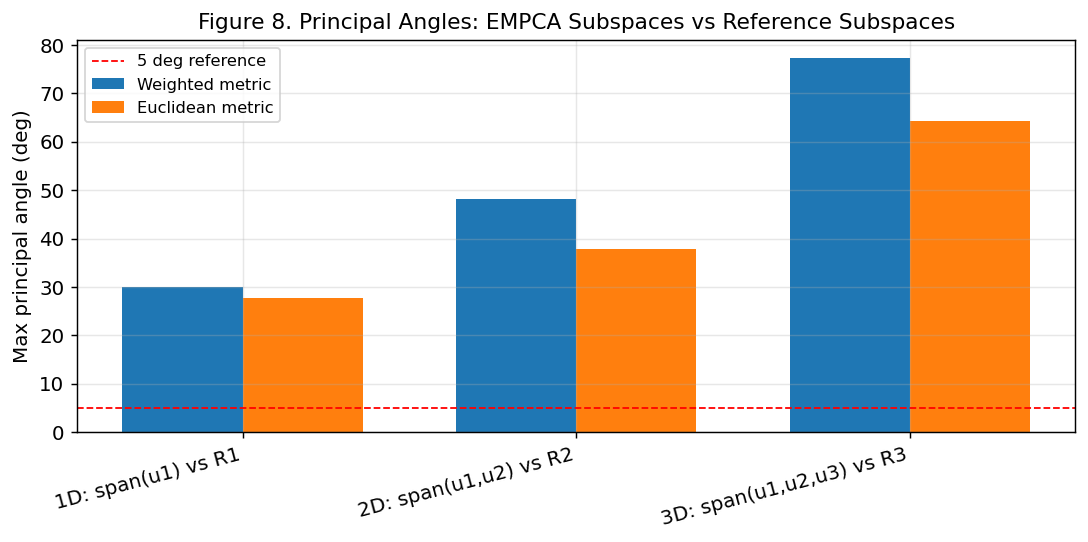

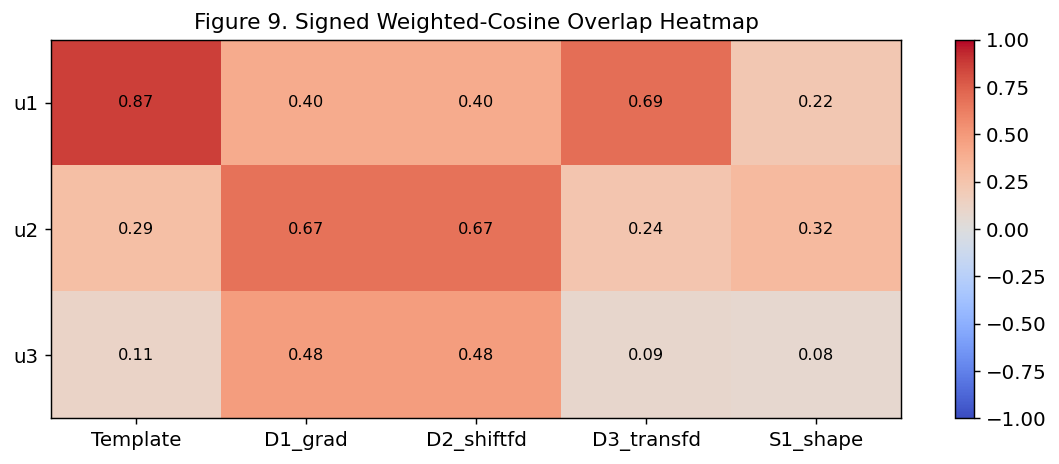

In [34]:
# Principal angles + overlap heatmap (Figures 8 and 9)

# Build reference subspaces
R1 = np.vstack([normalize_weighted(r_template_freq, W)])
R2 = np.vstack([
    normalize_weighted(r_template_freq, W),
    normalize_weighted(fixed_derivative_refs['D2_shiftfd_time_then_transform'], W),
])
R3 = np.vstack([
    normalize_weighted(r_template_freq, W),
    normalize_weighted(fixed_derivative_refs['D2_shiftfd_time_then_transform'], W),
    normalize_weighted(fixed_shape_ref, W),
])

U1 = np.vstack([normalize_weighted(U[0], W)])
U2s = np.vstack([normalize_weighted(U[0], W), normalize_weighted(U[1], W)])
U3s = np.vstack([normalize_weighted(U[0], W), normalize_weighted(U[1], W), normalize_weighted(U[2], W)])

ang1_w = weighted_principal_angles(U1, R1, W)
ang2_w = weighted_principal_angles(U2s, R2, W)
ang3_w = weighted_principal_angles(U3s, R3, W)

ones = np.ones_like(W)
ang1_e = weighted_principal_angles(U1, R1, ones)
ang2_e = weighted_principal_angles(U2s, R2, ones)
ang3_e = weighted_principal_angles(U3s, R3, ones)

print('Weighted principal angles 1D/2D/3D:', ang1_w, ang2_w, ang3_w)
print('Euclidean principal angles 1D/2D/3D:', ang1_e, ang2_e, ang3_e)

# Figure 8: principal-angle summary
labels = ['1D: span(u1) vs R1', '2D: span(u1,u2) vs R2', '3D: span(u1,u2,u3) vs R3']
vals_w = [float(np.max(ang1_w)), float(np.max(ang2_w)), float(np.max(ang3_w))]
vals_e = [float(np.max(ang1_e)), float(np.max(ang2_e)), float(np.max(ang3_e))]

x = np.arange(3)
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar(x-0.18, vals_w, width=0.36, label='Weighted metric')
ax.bar(x+0.18, vals_e, width=0.36, label='Euclidean metric')
ax.set_xticks(x, labels, rotation=15, ha='right')
ax.set_ylabel('Max principal angle (deg)')
ax.set_title('Figure 8. Principal Angles: EMPCA Subspaces vs Reference Subspaces')
ax.axhline(5.0, color='r', linestyle='--', linewidth=1.0, label='5 deg reference')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Figure 9: overlap heatmap (signed cosine, phase-aligned per pair)
ref_names = ['Template', 'D1_grad', 'D2_shiftfd', 'D3_transfd', 'S1_shape']
ref_vecs = [
    r_template_freq,
    fixed_derivative_refs['D1_grad_time_then_transform'],
    fixed_derivative_refs['D2_shiftfd_time_then_transform'],
    fixed_derivative_refs['D3_shiftfd_in_transformed_domain'],
    fixed_shape_ref,
]

H = np.zeros((3, len(ref_vecs)), dtype=float)
for i in range(3):
    ui = normalize_weighted(U[i], W)
    for j, rv in enumerate(ref_vecs):
        ra = align_phase_to_ref(rv, ui, W)
        H[i, j] = float(np.real(weighted_cosine(ui, ra, W)))

fig, ax = plt.subplots(figsize=(8.8, 3.7))
im = ax.imshow(H, aspect='auto', vmin=-1, vmax=1, cmap='coolwarm')
ax.set_yticks(np.arange(3), labels=['u1', 'u2', 'u3'])
ax.set_xticks(np.arange(len(ref_names)), labels=ref_names)
ax.set_title('Figure 9. Signed Weighted-Cosine Overlap Heatmap')
for i in range(H.shape[0]):
    for j in range(H.shape[1]):
        ax.text(j, i, f'{H[i,j]:.2f}', ha='center', va='center', color='black', fontsize=9)
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## 10. Stability Analysis

**Goal**  
Assess stability across weight/noise configurations.

**Method**  
Compare \(u_1\) alignment and 2D/3D subspace angles across all saved models.

**Interpretation Meaning**  
Stable \(u_1\) with rotating higher modes suggests a robust dominant mode with less unique higher-order bases.


                     model noise_type     weight_type  u1_cosine_real_to_ref  \
0     PSD_run1_sum_mmc.pkl        mmc           1/PSD               1.000000   
1    PSD_run1_sum_pink.pkl       pink           1/PSD               0.999196   
2   PSD_run1_sum_white.pkl      white           1/PSD               0.999304   
3    SNR2_run1_sum_mmc.pkl        mmc  SNR2=|H|^2/PSD               0.903466   
4   SNR2_run1_sum_pink.pkl       pink  SNR2=|H|^2/PSD               0.999344   
5  SNR2_run1_sum_white.pkl      white  SNR2=|H|^2/PSD               0.735914   

   sub2_max_angle_deg  sub3_max_angle_deg  
0            0.000002            0.000005  
1           29.995886           77.151004  
2           39.526494           86.506090  
3           76.445919           86.828093  
4           77.547614           89.266450  
5           87.294885           89.433959  


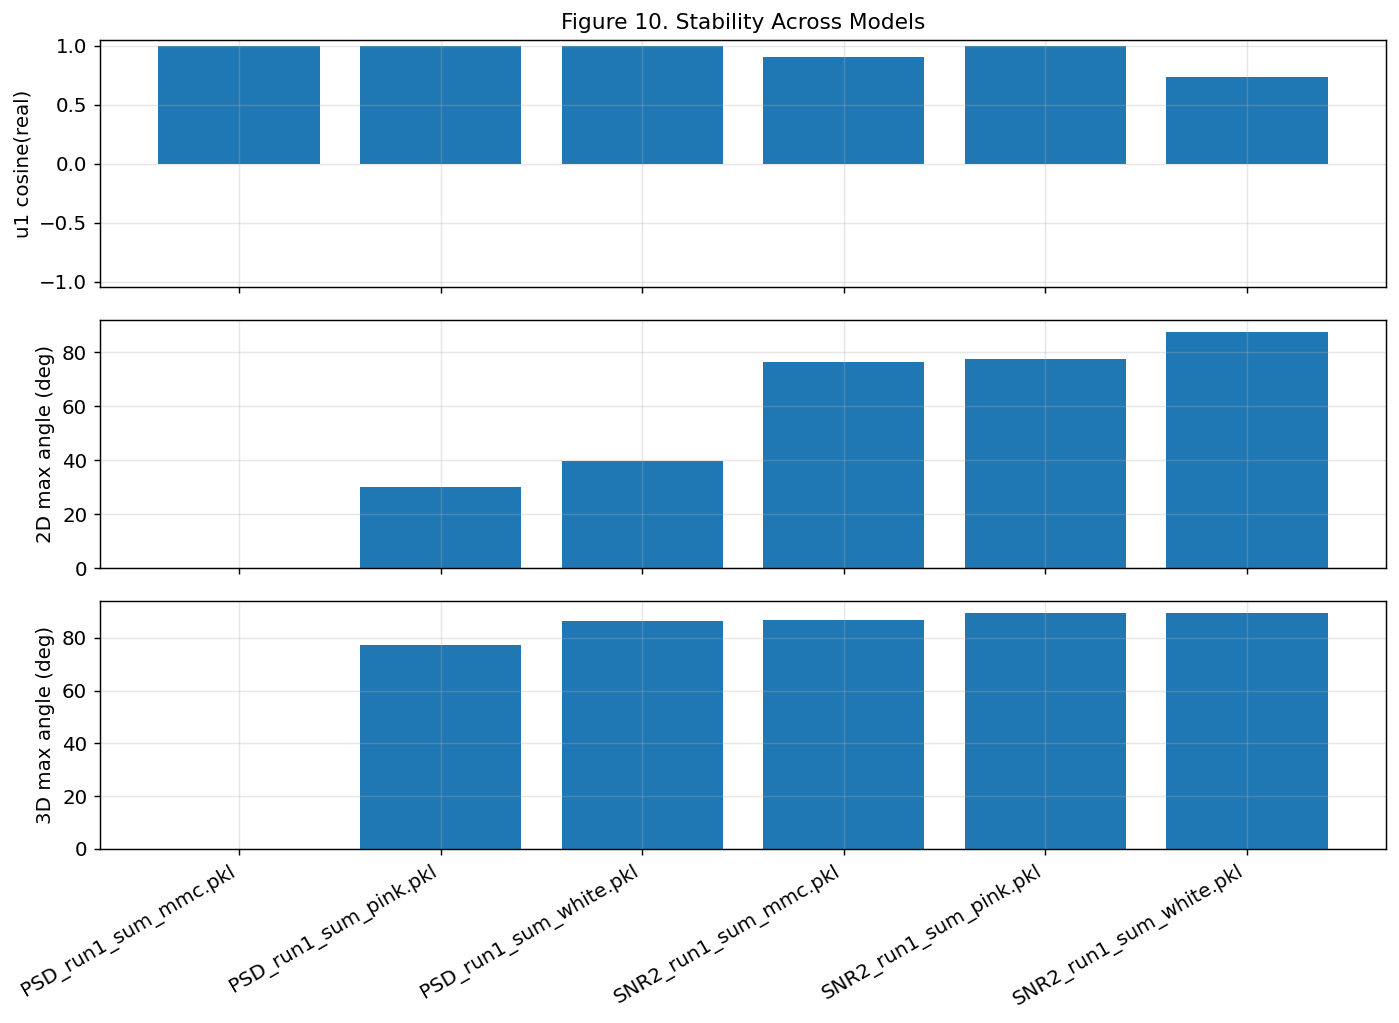

In [35]:
# Figure 10: stability across models
if not RUN_STABILITY:
    print('Stability section disabled')
    stability_df = pd.DataFrame()
else:
    model_files = sorted((repo_root / 'wk3' / 'models').glob('*.pkl'))
    rows = []

    U_ref = U
    u1_ref = normalize_weighted(U_ref[0], W)
    U2_ref = np.vstack([normalize_weighted(U_ref[0], W), normalize_weighted(U_ref[1], W)])
    U3_ref = np.vstack([normalize_weighted(U_ref[0], W), normalize_weighted(U_ref[1], W), normalize_weighted(U_ref[2], W)])

    for mf in model_files:
        with open(mf, 'rb') as f:
            a = pickle.load(f)
        p = a['pca'] if isinstance(a, dict) and 'pca' in a else a
        Um = np.asarray(getattr(p, 'eigvec', getattr(p, 'components_', None)), dtype=complex)
        if Um is None or Um.shape[0] < 3 or Um.shape[1] != U_ref.shape[1]:
            continue
        try:
            Wm = resolve_weight_vector(a, repo_root)
        except Exception:
            continue

        u1m = normalize_weighted(Um[0], Wm)
        u1m_a = align_phase_to_ref(u1m, u1_ref, W)
        c1 = weighted_cosine(u1_ref, u1m_a, W)

        U2m = np.vstack([normalize_weighted(Um[0], Wm), normalize_weighted(Um[1], Wm)])
        U3m = np.vstack([normalize_weighted(Um[0], Wm), normalize_weighted(Um[1], Wm), normalize_weighted(Um[2], Wm)])
        a2 = weighted_principal_angles(U2_ref, U2m, W)
        a3 = weighted_principal_angles(U3_ref, U3m, W)

        rows.append({
            'model': mf.name,
            'noise_type': a.get('noise_type', 'unknown') if isinstance(a, dict) else 'unknown',
            'weight_type': a.get('weight_type', 'unknown') if isinstance(a, dict) else 'unknown',
            'u1_cosine_real_to_ref': float(np.real(c1)),
            'sub2_max_angle_deg': float(np.max(a2)),
            'sub3_max_angle_deg': float(np.max(a3)),
        })

    stability_df = pd.DataFrame(rows).sort_values('model').reset_index(drop=True)
    print(stability_df)

    if not stability_df.empty:
        x = np.arange(len(stability_df))
        fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
        axes[0].bar(x, stability_df['u1_cosine_real_to_ref'])
        axes[0].set_ylabel('u1 cosine(real)')
        axes[0].set_ylim(-1.05, 1.05)
        axes[0].set_title('Figure 10. Stability Across Models')
        axes[0].grid(alpha=0.3)

        axes[1].bar(x, stability_df['sub2_max_angle_deg'])
        axes[1].set_ylabel('2D max angle (deg)')
        axes[1].grid(alpha=0.3)

        axes[2].bar(x, stability_df['sub3_max_angle_deg'])
        axes[2].set_ylabel('3D max angle (deg)')
        axes[2].set_xticks(x, stability_df['model'], rotation=30, ha='right')
        axes[2].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()


## 11. Summary Table (Mandatory)

**Goal**  
Condense evidence per component into paper-ready interpretation metrics.

**Method**  
Combine weighted cosine, weighted \(R^2\), perturbation sensitivity, and qualitative confidence.

**Interpretation Meaning**  
- **Weighted Cosine**: directional alignment in training metric  
- **\(R^2\)**: reconstruction quality by reference direction  
- **Perturbation Sensitivity**: whether coefficient responds to intended physical perturbation  
- **Interpretation Confidence**: conservative evidence strength, not certainty


In [36]:
# Build summary table

# u1 metrics already computed: cos_u1, r2_u1
u1_best_ref = 'Template'
u1_cos = float(np.real(cos_u1))
u1_r2 = float(r2_u1)

# u2 best candidate from derivative table
u2_best_idx = int(np.argmax(deriv_df['cosine_real'].values))
u2_best_ref = deriv_df.loc[u2_best_idx, 'candidate']
u2_cos = float(deriv_df.loc[u2_best_idx, 'cosine_real'])
u2_r2 = float(deriv_df.loc[u2_best_idx, 'R2'])

# u3 best candidate from shape table
u3_best_idx = int(np.argmax(shape_df['cosine_real'].values))
u3_best_ref = shape_df.loc[u3_best_idx, 'candidate']
u3_cos = float(shape_df.loc[u3_best_idx, 'cosine_real'])
u3_r2 = float(shape_df.loc[u3_best_idx, 'R2'])

# perturbation sensitivities
u1_sens = 'shift: low-to-moderate (inspect c1 curve)'
u2_sens = f'shift slope(c2)={c2_shift_slope:.4g}, corr(c2,t0)={c2_vs_t0_corr:.3f}'
u3_sens = f'shape span(c3)={c3_shape_sensitivity:.4g}'

# conservative confidence labels

def conf_label(cosv, r2v):
    if cosv > 0.9 and r2v > 0.8:
        return 'High'
    if cosv > 0.7 and r2v > 0.5:
        return 'Moderate'
    return 'Low/Moderate'

summary_df = pd.DataFrame([
    {
        'Component': 'u1',
        'Best Reference': u1_best_ref,
        'Weighted Cosine': u1_cos,
        'R2': u1_r2,
        'Perturbation Sensitivity': u1_sens,
        'Interpretation Confidence': conf_label(u1_cos, u1_r2),
    },
    {
        'Component': 'u2',
        'Best Reference': u2_best_ref,
        'Weighted Cosine': u2_cos,
        'R2': u2_r2,
        'Perturbation Sensitivity': u2_sens,
        'Interpretation Confidence': conf_label(u2_cos, u2_r2),
    },
    {
        'Component': 'u3',
        'Best Reference': u3_best_ref,
        'Weighted Cosine': u3_cos,
        'R2': u3_r2,
        'Perturbation Sensitivity': u3_sens,
        'Interpretation Confidence': conf_label(u3_cos, u3_r2),
    },
])

summary_df


,Component,Best Reference,Weighted Cosine,R2,Perturbation Sensitivity,Interpretation Confidence
0,u1,Template,0.865883,0.749754,shift: low-to-moderate (inspect c1 curve),Moderate
1,u2,D2_shiftfd_time_then_transform,0.674125,0.454445,"shift slope(c2)=0.5184, corr(c2,t0)=0.536",Low/Moderate
2,u3,S2_synthetic_broad_minus_narrow,0.477617,0.228118,shape span(c3)=166.4,Low/Moderate


## 12. Final Interpretation Section

### Key Conclusions to Report

1. **Is \(u_1\) template-like?**  
Use Figure 1/2 + weighted cosine + \(R^2\) to answer.

2. **Is \(u_2\) timing-like?**  
Use derivative comparisons + Figure 4 + Figure 5. If evidence is mixed, label as first residual deformation mode.

3. **Is \(u_3\) shape-like?**  
Use shape-candidate metrics + Figure 7. If weak, report mixed/higher-order morphology mode.

4. **Is interpretation unique or rotated?**  
Use principal angles and overlap heatmap: emphasize subspace alignment over strict component identity.

### Required Cautionary Statement

**Higher-order EMPCA components may represent rotated bases within a low-dimensional signal subspace rather than uniquely identifiable physical modes.**

### Safe Paper-Level Framing

In the current implementation, EMPCA learns dominant directions of a baseline-corrected, shift-invariant transformed pulse manifold. The first component is typically most template-aligned, while higher components should be interpreted through transformed-domain alignment, perturbation response, and subspace geometry rather than strict one-to-one physical identity.
